In [4]:
!pip install matplotlib numpy pandas -q

In [6]:
import numpy as np
import pandas as pd

np.random.seed(42)
meses = np.arange(1, 25)

cpu     = np.clip(20 + 2.3 * meses + np.random.normal(0, 3.5, 24), 10, 98)
ram     = np.clip(30 + 2.1 * meses + np.random.normal(0, 4.0, 24), 15, 99)
storage = np.clip(10 + 2.5 * meses + np.random.normal(0, 2.0, 24),  5, 99)

df = pd.DataFrame({
    "mes": meses,
    "cpu_uso": np.round(cpu, 2),
    "ram_uso": np.round(ram, 2),
    "almacenamiento_uso": np.round(storage, 2)
})

print(" Dataset listo:")
print(df.to_string(index=False))

 Dataset listo:
 mes  cpu_uso  ram_uso  almacenamiento_uso
   1    24.04    29.92               13.19
   2    24.12    34.64               11.47
   3    29.17    31.70               18.15
   4    34.53    39.90               19.23
   5    30.68    38.10               21.15
   6    32.98    41.43               26.22
   7    41.63    42.29               29.56
   8    41.09    54.21               31.86
   9    39.06    48.85               30.82
  10    44.90    46.77               34.38
  11    43.68    56.39               38.16
  12    45.97    50.32               41.95
  13    50.75    58.14               41.54
  14    45.50    51.56               44.63
  15    48.46    56.19               45.29
  16    54.83    64.39               47.61
  17    55.56    68.65               54.13
  18    62.50    68.49               57.71
  19    60.52    69.44               57.36
  20    61.06    70.80               62.01
  21    73.43    68.19               63.22
  22    69.81    73.32               6

In [7]:
class MinimoCuadrados:
    def __init__(self):
        self.pendiente  = None
        self.intercepto = None
        self.r_cuadrado = None
        self.n          = 0

    def ajustar(self, x, y):
        x, y = np.asarray(x, float), np.asarray(y, float)
        n    = len(x)
        sx, sy   = x.sum(), y.sum()
        sxy, sx2 = (x * y).sum(), (x ** 2).sum()
        denom = n * sx2 - sx ** 2
        self.pendiente  = (n * sxy - sx * sy) / denom
        self.intercepto = (sy - self.pendiente * sx) / n
        yhat    = self.predecir(x)
        ss_res  = ((y - yhat) ** 2).sum()
        ss_tot  = ((y - y.mean()) ** 2).sum()
        self.r_cuadrado = 1 - ss_res / ss_tot
        self.n  = n
        return self

    def predecir(self, x):
        return self.pendiente * np.asarray(x, float) + self.intercepto

print(" Clase lista")

 Clase lista


In [8]:
x = df["mes"].values

metricas = {
    "CPU (%)":             df["cpu_uso"].values,
    "RAM (%)":             df["ram_uso"].values,
    "Almacenamiento (%)":  df["almacenamiento_uso"].values,
}

modelos = {}
for nombre, y in metricas.items():
    m = MinimoCuadrados().ajustar(x, y)
    modelos[nombre] = m
    print(f"\n{'='*45}")
    print(f"  {nombre}")
    print(f"{'='*45}")
    print(f"  Ecuación : ŷ = {m.pendiente:.4f}·x + {m.intercepto:.4f}")
    print(f"  R²       : {m.r_cuadrado:.4f}  ({m.r_cuadrado*100:.2f}%)")


  CPU (%)
  Ecuación : ŷ = 2.1029·x + 21.9475
  R²       : 0.9581  (95.81%)

  RAM (%)
  Ecuación : ŷ = 2.1001·x + 28.9478
  R²       : 0.9462  (94.62%)

  Almacenamiento (%)
  Ecuación : ŷ = 2.5659·x + 9.3700
  R²       : 0.9916  (99.16%)


In [11]:
x_futuro = np.arange(25, 37)

filas = []
for mes in x_futuro:
    fila = {"Mes": mes}
    for nombre, modelo in modelos.items():
        col = nombre.split(" ")[0]
        val = round(float(modelo.predecir(mes)), 2)
        fila[f"{col} (%)"] = val
    filas.append(fila)

df_pred = pd.DataFrame(filas)
print("\nPredicciones próximos 12 meses:\n")
print(df_pred.to_string(index=False))

print("\nAlertas (uso > 85%):")
for col in ["CPU (%)", "RAM (%)", "Almacenamiento (%)"]:
    criticos = df_pred[df_pred[col] >= 85]["Mes"]
    if not criticos.empty:
        print(f"   {col} → supera 85% en el mes {criticos.iloc[0]}")


Predicciones próximos 12 meses:

 Mes  CPU (%)  RAM (%)  Almacenamiento (%)
  25    74.52    81.45               73.52
  26    76.62    83.55               76.08
  27    78.73    85.65               78.65
  28    80.83    87.75               81.22
  29    82.93    89.85               83.78
  30    85.04    91.95               86.35
  31    87.14    94.05               88.91
  32    89.24    96.15               91.48
  33    91.34    98.25               94.04
  34    93.45   100.35               96.61
  35    95.55   102.45               99.18
  36    97.65   104.55              101.74

Alertas (uso > 85%):
   CPU (%) → supera 85% en el mes 30
   RAM (%) → supera 85% en el mes 27
   Almacenamiento (%) → supera 85% en el mes 30


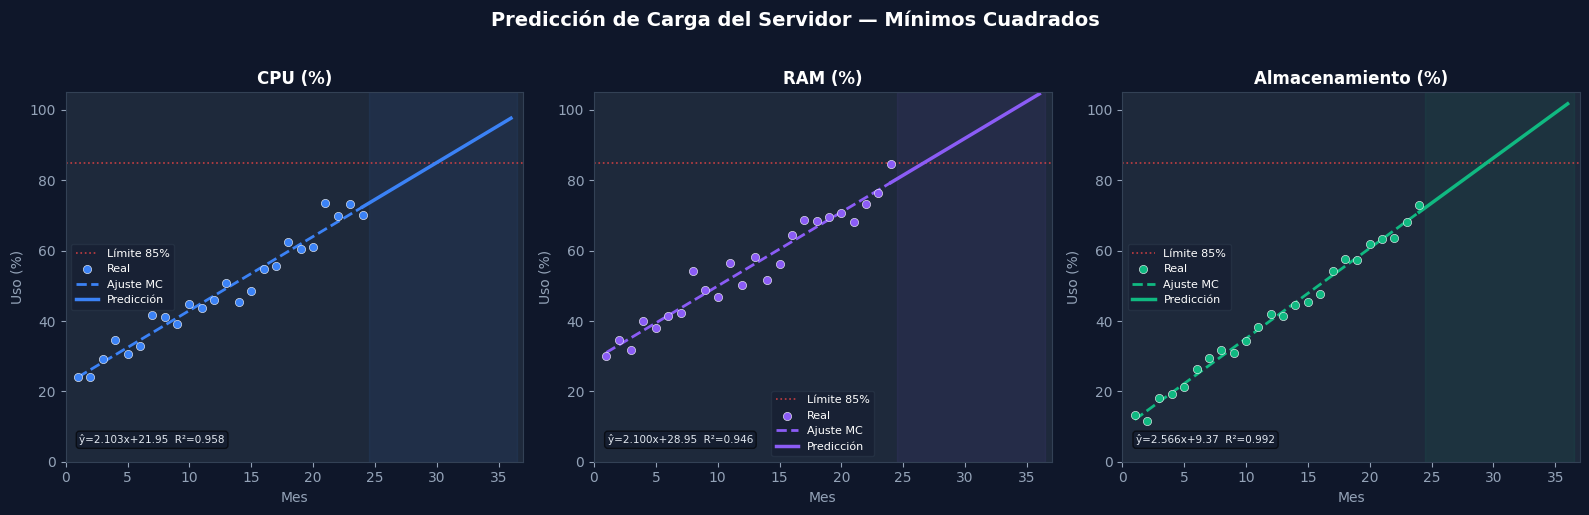

Gráfica guardada como prediccion_servidor.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

colores = {
    "CPU (%)":            "#3b82f6",
    "RAM (%)":            "#8b5cf6",
    "Almacenamiento (%)": "#10b981",
}

fig = plt.figure(figsize=(16, 5), facecolor="#0f172a")
axes = [fig.add_subplot(1, 3, i+1) for i in range(3)]

x_hist   = df["mes"].values
x_futuro = np.arange(25, 37)
cols_df  = {
    "CPU (%)":            "cpu_uso",
    "RAM (%)":            "ram_uso",
    "Almacenamiento (%)": "almacenamiento_uso",
}

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    color  = colores[nombre]
    y_hist = df[cols_df[nombre]].values

    ax.set_facecolor("#1e293b")
    ax.axvspan(24.5, 36.5, alpha=0.07, color=color)
    ax.axhline(85, color="#ef4444", lw=1.2, ls=":", alpha=0.8, label="Límite 85%")
    ax.scatter(x_hist, y_hist, color=color, s=35, zorder=5,
               edgecolors="white", linewidths=0.4, label="Real")

    x_fit = np.linspace(1, 24, 200)
    ax.plot(x_fit, modelo.predecir(x_fit),
            color=color, lw=2, ls="--", label="Ajuste MC")

    x_pred = np.linspace(24, 36, 100)
    ax.plot(x_pred, modelo.predecir(x_pred),
            color=color, lw=2.5, label="Predicción")

    ax.set_title(nombre, color="white", fontsize=12, fontweight="bold")
    ax.set_xlabel("Mes", color="#94a3b8")
    ax.set_ylabel("Uso (%)", color="#94a3b8")
    ax.tick_params(colors="#94a3b8")
    ax.set_ylim(0, 105)
    ax.set_xlim(0, 37)
    for sp in ax.spines.values():
        sp.set_edgecolor("#334155")
    ax.legend(fontsize=8, labelcolor="white",
              facecolor="#0f172a", edgecolor="#334155", framealpha=0.4)

    eq = f"ŷ={modelo.pendiente:.3f}x+{modelo.intercepto:.2f}  R²={modelo.r_cuadrado:.3f}"
    ax.text(0.03, 0.05, eq, transform=ax.transAxes, fontsize=7.5,
            color="#e2e8f0", bbox=dict(boxstyle="round", facecolor="#0f172a", alpha=0.6))

plt.suptitle("Predicción de Carga del Servidor — Mínimos Cuadrados",
             color="white", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("prediccion_servidor.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Gráfica guardada como prediccion_servidor.png")